# Clasificación de datos planares con una capa oculta

Bienvenido a tu tarea de programación de la semana 3. Es hora de construir tu primera red neuronal, que tendrá una capa oculta. Ahora notarás una gran diferencia entre este modelo y el que implementaste previamente usando regresión logística.

Al final de esta tarea, podrás:

- Implementar una red neuronal de clasificación de 2 clases con una sola capa oculta
- Usar unidades con una función de activación no lineal, como tanh
- Calcular la pérdida de entropía cruzada
- Implementar propagación hacia adelante y hacia atrás

## Nota Importante sobre el Envío al AutoGrader

Antes de enviar tu tarea al AutoGrader, asegúrate de no estar haciendo lo siguiente:

1. No has añadido ninguna instrucción `print` _extra_ en la tarea.
2. No has añadido ninguna celda de código _extra_ en la tarea.
3. No has cambiado ninguno de los parámetros de las funciones.
4. No estás usando variables globales dentro de tus ejercicios calificados. A menos que se te indique específicamente, por favor abstente de hacerlo y usa variables locales en su lugar.
5. No estás cambiando el código de la tarea donde no es necesario, como crear variables _extra_.

Si haces cualquiera de lo anterior, obtendrás algo como `Grader Error: Grader feedback not found` (o un error inesperado similar) al enviar tu tarea. Antes de pedir ayuda/depurar los errores en tu tarea, verifica esto primero. Si este es el caso y no recuerdas los cambios que has hecho, puedes obtener una copia nueva de la tarea siguiendo estas [instrucciones](https://www.coursera.org/learn/neural-networks-deep-learning/supplement/xLEC1/optional-downloading-your-notebook-downloading-your-workspace-and-refreshing).

## Tabla de Contenidos
- [1 - Paquetes](#1)
- [2 - Cargar el Conjunto de Datos](#2)
    - [Ejercicio 1](#ex-1)
- [3 - Regresión Logística Simple](#3)
- [4 - Modelo de Red Neuronal](#4)
    - [4.1 - Definir la estructura de la red neuronal](#4-1)
        - [Ejercicio 2 - layer_sizes](#ex-2)
    - [4.2 - Inicializar los parámetros del modelo](#4-2)
        - [Ejercicio 3 - initialize_parameters](#ex-3)
    - [4.3 - El Bucle](#4-3)
        - [Ejercicio 4 - forward_propagation](#ex-4)
    - [4.4 - Calcular el Costo](#4-4)
        - [Ejercicio 5 - compute_cost](#ex-5)
    - [4.5 - Implementar Retropropagación](#4-5)
        - [Ejercicio 6 - backward_propagation](#ex-6)
    - [4.6 - Actualizar Parámetros](#4-6)
        - [Ejercicio 7 - update_parameters](#ex-7)
    - [4.7 - Integración](#4-7)
        - [Ejercicio 8 - nn_model](#ex-8)
- [5 - Probar el Modelo](#5)
    - [5.1 - Predecir](#5-1)
        - [Ejercicio 9 - predict](#ex-9)
    - [5.2 - Probar el Modelo en el Conjunto de Datos Planar](#5-2)
- [6 - Ajustar el tamaño de la capa oculta (ejercicio opcional/no calificado)](#6)
- [7 - Rendimiento en otros conjuntos de datos](#7)

<a name='1'></a>
# 1 - Paquetes

Primero importa todos los paquetes que necesitarás durante esta tarea.

- [numpy](https://www.numpy.org/) es el paquete fundamental para computación científica con Python.
- [sklearn](http://scikit-learn.org/stable/) proporciona herramientas simples y eficientes para minería y análisis de datos.
- [matplotlib](http://matplotlib.org) es una biblioteca para graficar en Python.
- testCases proporciona algunos ejemplos de prueba para evaluar la corrección de tus funciones
- planar_utils proporciona varias funciones útiles usadas en esta tarea

In [1]:
### v3.0

In [6]:
# Package imports
import numpy as np
import copy
import matplotlib.pyplot as plt
from testCases_v2 import *
from public_tests import *
import sklearn
import sklearn.datasets
import sklearn.linear_model
from planar_utils import plot_decision_boundary, sigmoid, load_planar_dataset, load_extra_datasets

%matplotlib inline

%load_ext autoreload
%autoreload 2

<a name='2'></a>
# 2 - Cargar el Conjunto de Datos



In [7]:
X, Y = load_planar_dataset()

Visualiza el conjunto de datos usando matplotlib. Los datos parecen una "flor" con algunos puntos rojos (etiqueta y=0) y algunos azules (y=1). Tu objetivo es construir un modelo que se ajuste a estos datos. En otras palabras, queremos que el clasificador defina regiones como rojas o azules.

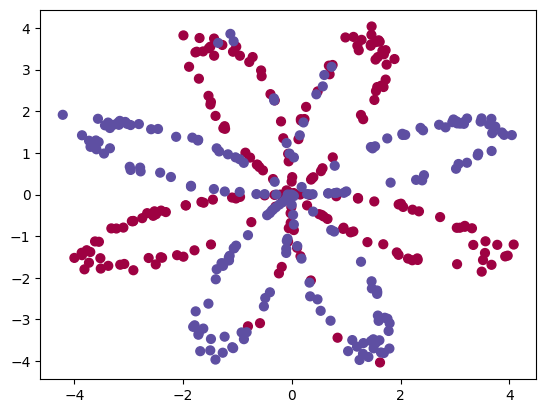

In [8]:
# Visualize the data:
plt.scatter(X[0, :], X[1, :], c=Y, s=40, cmap=plt.cm.Spectral);

Tienes:
    - un arreglo numpy (matriz) X que contiene tus características (x1, x2)
    - un arreglo numpy (vector) Y que contiene tus etiquetas (rojo:0, azul:1).

Primero, obtén una mejor idea de cómo son tus datos.

<a name='ex-1'></a>
### Ejercicio 1

¿Cuántos ejemplos de entrenamiento tienes? Además, ¿cuál es la `forma` (shape) de las variables `X` y `Y`?

**Pista**: ¿Cómo obtienes la forma de un arreglo numpy? [(ayuda)](https://docs.scipy.org/doc/numpy/reference/generated/numpy.ndarray.shape.html)

In [ ]:
# (≈ 3 lines of code)
# shape_X = ...
# shape_Y = ...
# training set size
# m = ...
# YOUR CODE STARTS HERE

shape_X = X.shape  # X.shape devuelve (2, 400) — 2 características (x1, x2) y 400 ejemplos
shape_Y = Y.shape  # Y.shape devuelve (1, 400) — 1 etiqueta por cada ejemplo
m = X.shape[1]    # m = X.shape[1] = 400 ejemplos de entrenamiento

# YOUR CODE ENDS HERE

print ('The shape of X is: ' + str(shape_X))    # X.shape[0] da el número de filas de X (características de entrada)
print ('The shape of Y is: ' + str(shape_Y))    # n_h = 4 se fija manualmente como indica el enunciado
print ('I have m = %d training examples!' % (m)) # Y.shape[0] da el número de filas de Y (neuronas de salida)

The shape of X is: (2, 400)
The shape of Y is: (1, 400)
I have m = 400 training examples!


**Resultado Esperado**:

<table style="width:20%">
  <tr>
    <td> forma de X </td>
    <td> (2, 400) </td>
  </tr>
  <tr>
    <td>forma de Y</td>
    <td>(1, 400) </td>
    </tr>
    <tr>
    <td>m</td>
    <td> 400 </td>
  </tr>
</table>

<a name='3'></a>
## 3 - Regresión Logística Simple

Antes de construir una red neuronal completa, verifiquemos cómo se desempeña la regresión logística en este problema. Puedes usar las funciones integradas de sklearn para esto. Ejecuta el código de abajo para entrenar un clasificador de regresión logística en el conjunto de datos.

In [ ]:
# Train the logistic regression classifier
clf = sklearn.linear_model.LogisticRegressionCV();
clf.fit(X.T, Y.T);

Ahora puedes graficar la frontera de decisión de estos modelos. Ejecuta el código de abajo.

In [ ]:
# Plot the decision boundary for logistic regression
plot_decision_boundary(lambda x: clf.predict(x), X, Y)
plt.title("Logistic Regression")

# Print accuracy
LR_predictions = clf.predict(X.T)
print ('Accuracy of logistic regression: %d ' % float((np.dot(Y,LR_predictions) + np.dot(1-Y,1-LR_predictions))/float(Y.size)*100) +
       '% ' + "(percentage of correctly labelled datapoints)")

**Resultado Esperado**:

<table style="width:20%">
  <tr>
    <td>Precisión</td>
    <td> 47% </td>
  </tr>

</table>


**Interpretación**: El conjunto de datos no es linealmente separable, por lo que la regresión logística no funciona bien. Esperemos que una red neuronal lo haga mejor. ¡Intentémoslo ahora!

<a name='4'></a>
## 4 - Modelo de Red Neuronal

La regresión logística no funcionó bien en el conjunto de datos de la flor. A continuación, vas a entrenar una Red Neuronal con una sola capa oculta y ver cómo maneja el mismo problema.

**El modelo**:
<img src="images/classification_kiank.png" style="width:600px;height:300px;">

**Matemáticamente**:

Para un ejemplo $x^{(i)}$:

$$z^{[1] (i)} =  W^{[1]} x^{(i)} + b^{[1]}\tag{1}$$
$$a^{[1] (i)} = \tanh(z^{[1] (i)})\tag{2}$$
$$z^{[2] (i)} = W^{[2]} a^{[1] (i)} + b^{[2]}\tag{3}$$
$$\hat{y}^{(i)} = a^{[2] (i)} = \sigma(z^{ [2] (i)})\tag{4}$$
$$y^{(i)}_{\text{prediccion}} = \begin{cases} 1 & \text{si } a^{[2](i)} > 0.5 \\ 0 & \text{en caso contrario} \end{cases}\tag{5}$$
Dadas las predicciones sobre todos los ejemplos, también puedes calcular el costo $J$ de la siguiente manera:

$$J = - \frac{1}{m} \sum\limits_{i = 0}^{m} \large\left(\small y^{(i)}\log\left(a^{[2] (i)}\right) + (1-y^{(i)})\log\left(1- a^{[2] (i)}\right)  \large  \right) \small \tag{6}$$

**Recordatorio**: La metodología general para construir una Red Neuronal es:
    1. Definir la estructura de la red neuronal (# de unidades de entrada, # de unidades ocultas, etc).
    2. Inicializar los parámetros del modelo
    3. Bucle:
        - Implementar propagación hacia adelante
        - Calcular la pérdida
        - Implementar retropropagación para obtener los gradientes
        - Actualizar parámetros (descenso de gradiente)

En la práctica, a menudo construirás funciones auxiliares para calcular los pasos 1-3, luego las fusionarás en una función llamada `nn_model()`. Una vez que hayas construido `nn_model()` y aprendido los parámetros correctos, puedes hacer predicciones sobre nuevos datos.

<a name='4-1'></a>
### 4.1 - Definir la estructura de la red neuronal ####

<a name='ex-2'></a>
### Ejercicio 2 - layer_sizes

Define tres variables:
- n_x: el tamaño de la capa de entrada
- n_h: el tamaño de la capa oculta (**establece esto en 4, como `n_h = 4`, pero solo para este Ejercicio 2**)
- n_y: el tamaño de la capa de salida

**Pista**: Usa las formas de X y Y para encontrar n_x y n_y. También, fija el tamaño de la capa oculta en 4.

In [10]:
# GRADED FUNCTION: layer_sizes

def layer_sizes(X, Y):
    """
    Arguments:
    X -- input dataset of shape (input size, number of examples)
    Y -- labels of shape (output size, number of examples)
    
    Returns:
    n_x -- the size of the input layer
    n_h -- the size of the hidden layer
    n_y -- the size of the output layer
    """
    #(≈ 3 lines of code)
    # n_x = ... 
    # n_h = ...
    # n_y = ... 
    # YOUR CODE STARTS HERE
    
    n_x = X.shape[0]
    n_h = 4
    n_y = Y.shape[0]
    
    # YOUR CODE ENDS HERE
    return (n_x, n_h, n_y)

In [11]:
t_X, t_Y = layer_sizes_test_case()
(n_x, n_h, n_y) = layer_sizes(t_X, t_Y)
print("The size of the input layer is: n_x = " + str(n_x))
print("The size of the hidden layer is: n_h = " + str(n_h))
print("The size of the output layer is: n_y = " + str(n_y))

layer_sizes_test(layer_sizes)

The size of the input layer is: n_x = 5
The size of the hidden layer is: n_h = 4
The size of the output layer is: n_y = 2
All tests passed!


***Resultado esperado***
```
The size of the input layer is: n_x = 5
The size of the hidden layer is: n_h = 4
The size of the output layer is: n_y = 2
All tests passed!
```

<a name='4-2'></a>
### 4.2 - Inicializar los parámetros del modelo ####

<a name='ex-3'></a>
### Ejercicio 3 - initialize_parameters

Implementa la función `initialize_parameters()`.

**Instrucciones**:
- Asegúrate de que los tamaños de tus parámetros sean correctos. Consulta la figura de la red neuronal de arriba si es necesario.
- Inicializarás las matrices de pesos con valores aleatorios.
    - Usa: `np.random.randn(a,b) * 0.01` para inicializar aleatoriamente una matriz de forma (a,b).
- Inicializarás los vectores de sesgo como ceros.
    - Usa: `np.zeros((a,b))` para inicializar una matriz de forma (a,b) con ceros.

In [12]:
# GRADED FUNCTION: initialize_parameters

def initialize_parameters(n_x, n_h, n_y):
    """
    Argument:
    n_x -- size of the input layer
    n_h -- size of the hidden layer
    n_y -- size of the output layer
    
    Returns:
    params -- python dictionary containing your parameters:
                    W1 -- weight matrix of shape (n_h, n_x)
                    b1 -- bias vector of shape (n_h, 1)
                    W2 -- weight matrix of shape (n_y, n_h)
                    b2 -- bias vector of shape (n_y, 1)
    """    
    #(≈ 4 lines of code)
    # W1 = ...
    # b1 = ...
    # W2 = ...
    # b2 = ...
    # YOUR CODE STARTS HERE
    
    W1 = np.random.randn(n_h, n_x) * 0.01
    b1 = np.zeros((n_h, 1))
    W2 = np.random.randn(n_y, n_h) * 0.01
    b2 = np.zeros((n_y, 1))
    
    # YOUR CODE ENDS HERE

    parameters = {"W1": W1,
                  "b1": b1,
                  "W2": W2,
                  "b2": b2}
    
    return parameters

In [13]:
np.random.seed(2)
n_x, n_h, n_y = initialize_parameters_test_case()
parameters = initialize_parameters(n_x, n_h, n_y)

print("W1 = " + str(parameters["W1"]))
print("b1 = " + str(parameters["b1"]))
print("W2 = " + str(parameters["W2"]))
print("b2 = " + str(parameters["b2"]))

initialize_parameters_test(initialize_parameters)

W1 = [[-0.00416758 -0.00056267]
 [-0.02136196  0.01640271]
 [-0.01793436 -0.00841747]
 [ 0.00502881 -0.01245288]]
b1 = [[0.]
 [0.]
 [0.]
 [0.]]
W2 = [[-0.01057952 -0.00909008  0.00551454  0.02292208]]
b2 = [[0.]]
All tests passed!


**Resultado esperado**
```
W1 = [[-0.00416758 -0.00056267]
 [-0.02136196  0.01640271]
 [-0.01793436 -0.00841747]
 [ 0.00502881 -0.01245288]]
b1 = [[0.]
 [0.]
 [0.]
 [0.]]
W2 = [[-0.01057952 -0.00909008  0.00551454  0.02292208]]
b2 = [[0.]]
All tests passed!
```

<a name='4-3'></a>
### 4.3 - El Bucle

<a name='ex-4'></a>
### Ejercicio 4 - forward_propagation

Implementa `forward_propagation()` usando las siguientes ecuaciones:

$$Z^{[1]} =  W^{[1]} X + b^{[1]}\tag{1}$$
$$A^{[1]} = \tanh(Z^{[1]})\tag{2}$$
$$Z^{[2]} = W^{[2]} A^{[1]} + b^{[2]}\tag{3}$$
$$\hat{Y} = A^{[2]} = \sigma(Z^{[2]})\tag{4}$$


**Instrucciones**:

- Revisa la representación matemática de tu clasificador en la figura de arriba.
- Usa la función `sigmoid()`. Está integrada (importada) en este notebook.
- Usa la función `np.tanh()`. Es parte de la biblioteca numpy.
- Implementa usando estos pasos:
    1. Recupera cada parámetro del diccionario "parameters" (que es la salida de `initialize_parameters()`) usando `parameters[".."]`.
    2. Implementa la Propagación hacia Adelante. Calcula $Z^{[1]}, A^{[1]}, Z^{[2]}$ y $A^{[2]}$ (el vector de todas tus predicciones sobre todos los ejemplos del conjunto de entrenamiento).
- Los valores necesarios en la retropropagación se almacenan en "cache". El cache se dará como entrada a la función de retropropagación.

In [14]:
# GRADED FUNCTION:forward_propagation

def forward_propagation(X, parameters):
    """
    Argument:
    X -- input data of size (n_x, m)
    parameters -- python dictionary containing your parameters (output of initialization function)
    
    Returns:
    A2 -- The sigmoid output of the second activation
    cache -- a dictionary containing "Z1", "A1", "Z2" and "A2"
    """
    # Retrieve each parameter from the dictionary "parameters"
    #(≈ 4 lines of code)
    # W1 = ...
    # b1 = ...
    # W2 = ...
    # b2 = ...
    # YOUR CODE STARTS HERE
    
    W1 = parameters["W1"]
    b1 = parameters["b1"]
    W2 = parameters["W2"]
    b2 = parameters["b2"]

    
    # YOUR CODE ENDS HERE
    
    # Implement Forward Propagation to calculate A2 (probabilities)
    # (≈ 4 lines of code)
    # Z1 = ...
    # A1 = ...
    # Z2 = ...
    # A2 = ...
    # YOUR CODE STARTS HERE
    
    Z1 = np.dot(W1, X) + b1
    A1 = np.tanh(Z1)
    Z2 = np.dot(W2, A1) + b2
    A2 = sigmoid(Z2)
    
    # YOUR CODE ENDS HERE
    
    assert(A2.shape == (1, X.shape[1]))
    
    cache = {"Z1": Z1,
             "A1": A1,
             "Z2": Z2,
             "A2": A2}
    
    return A2, cache

In [15]:
t_X, parameters = forward_propagation_test_case()
A2, cache = forward_propagation(t_X, parameters)
print("A2 = " + str(A2))

forward_propagation_test(forward_propagation)

A2 = [[0.21292656 0.21274673 0.21295976]]
All tests passed!


***Resultado esperado***
```
A2 = [[0.21292656 0.21274673 0.21295976]]
All tests passed!
```

<a name='4-4'></a>
### 4.4 - Calcular el Costo

Ahora que has calculado $A^{[2]}$ (en la variable de Python "`A2`"), que contiene $a^{[2](i)}$ para todos los ejemplos, puedes calcular la función de costo de la siguiente manera:

$$J = - \frac{1}{m} \sum\limits_{i = 1}^{m} \large{(} \small y^{(i)}\log\left(a^{[2] (i)}\right) + (1-y^{(i)})\log\left(1- a^{[2] (i)}\right) \large{)} \small\tag{13}$$

<a name='ex-5'></a>
### Ejercicio 5 - compute_cost

Implementa `compute_cost()` para calcular el valor del costo $J$.

**Instrucciones**:
- Hay muchas formas de implementar la pérdida de entropía cruzada. Esta es una forma de implementar una parte de la ecuación sin bucles for:
$- \sum\limits_{i=1}^{m}  y^{(i)}\log(a^{[2](i)})$:
```python
logprobs = np.multiply(np.log(A2),Y)
cost = - np.sum(logprobs)
```

- Usa eso para construir la expresión completa de la función de costo.

**Notas**:

- Puedes usar `np.multiply()` y luego `np.sum()` o directamente `np.dot()`.
- Si usas `np.multiply` seguido de `np.sum`, el resultado final será de tipo `float`, mientras que si usas `np.dot`, el resultado será un arreglo numpy 2D.
- Puedes usar `np.squeeze()` para eliminar dimensiones redundantes (en el caso de un solo float, esto se reducirá a un arreglo de dimensión cero).
- También puedes convertir el arreglo a tipo `float` usando `float()`.

In [16]:
# GRADED FUNCTION: compute_cost

def compute_cost(A2, Y):
    """
    Computes the cross-entropy cost given in equation (13)
    
    Arguments:
    A2 -- The sigmoid output of the second activation, of shape (1, number of examples)
    Y -- "true" labels vector of shape (1, number of examples)

    Returns:
    cost -- cross-entropy cost given equation (13)
    
    """
    
    m = Y.shape[1] # number of examples

    # Compute the cross-entropy cost
    # (≈ 2 lines of code)
    # logprobs = ...
    # cost = ...
    # YOUR CODE STARTS HERE
    
    logprobs = np.multiply(np.log(A2), Y) + np.multiply(np.log(1 - A2), (1 - Y))
    cost = -1/m * np.sum(logprobs)
    
    # YOUR CODE ENDS HERE
    
    cost = float(np.squeeze(cost))  # makes sure cost is the dimension we expect. 
                                    # E.g., turns [[17]] into 17 
    
    return cost

In [17]:
A2, t_Y = compute_cost_test_case()
cost = compute_cost(A2, t_Y)
print("cost = " + str(compute_cost(A2, t_Y)))

compute_cost_test(compute_cost)

cost = 0.6930587610394646
All tests passed!


***Resultado esperado***
```
cost = 0.6930587610394646
All tests passed!
```

<a name='4-5'></a>
### 4.5 - Implementar Retropropagación

Usando el cache calculado durante la propagación hacia adelante, ahora puedes implementar la retropropagación.

<a name='ex-6'></a>
### Ejercicio 6 - backward_propagation

Implementa la función `backward_propagation()`.

**Instrucciones**:
La retropropagación es usualmente la parte más difícil (más matemática) en deep learning. Para ayudarte, aquí está nuevamente la diapositiva de la clase sobre retropropagación. Querrás usar las seis ecuaciones del lado derecho de esta diapositiva, ya que estás construyendo una implementación vectorizada.

<img src="images/grad_summary.png" style="width:600px;height:300px;">
<caption><center><font color='purple'><b>Figura 1</b>: Retropropagación. Usa las seis ecuaciones de la derecha.</font></center></caption>

- Consejos:
    - Para calcular dZ1 necesitarás calcular $g^{[1]'}(Z^{[1]})$. Como $g^{[1]}(.)$ es la función de activación tanh, si $a = g^{[1]}(z)$ entonces $g^{[1]'}(z) = 1-a^2$. Así que puedes calcular
    $g^{[1]'}(Z^{[1]})$ usando `(1 - np.power(A1, 2))`.

In [18]:
# GRADED FUNCTION: backward_propagation

def backward_propagation(parameters, cache, X, Y):
    """
    Implement the backward propagation using the instructions above.
    
    Arguments:
    parameters -- python dictionary containing our parameters 
    cache -- a dictionary containing "Z1", "A1", "Z2" and "A2".
    X -- input data of shape (2, number of examples)
    Y -- "true" labels vector of shape (1, number of examples)
    
    Returns:
    grads -- python dictionary containing your gradients with respect to different parameters
    """
    m = X.shape[1]
    
    # First, retrieve W1 and W2 from the dictionary "parameters".
    #(≈ 2 lines of code)
    # W1 = ...
    # W2 = ...
    # YOUR CODE STARTS HERE
    
    W1 = parameters["W1"]
    W2 = parameters["W2"]
    
    # YOUR CODE ENDS HERE
        
    # Retrieve also A1 and A2 from dictionary "cache".
    #(≈ 2 lines of code)
    # A1 = ...
    # A2 = ...
    # YOUR CODE STARTS HERE
    
    A1 = cache["A1"]
    A2 = cache["A2"]
    
    # YOUR CODE ENDS HERE
    
    # Backward propagation: calculate dW1, db1, dW2, db2. 
    #(≈ 6 lines of code, corresponding to 6 equations on slide above)
    # dZ2 = ...
    # dW2 = ...
    # db2 = ...
    # dZ1 = ...
    # dW1 = ...
    # db1 = ...
    # YOUR CODE STARTS HERE
    
    dZ2 = A2 - Y
    dW2 = 1/m * np.dot(dZ2, A1.T)
    db2 = 1/m * np.sum(dZ2, axis=1, keepdims=True)
    dZ1 = np.dot(W2.T, dZ2) * (1 - np.power(A1, 2))
    dW1 = 1/m * np.dot(dZ1, X.T)
    db1 = 1/m * np.sum(dZ1, axis=1, keepdims=True)
    
    # YOUR CODE ENDS HERE
    
    grads = {"dW1": dW1,
             "db1": db1,
             "dW2": dW2,
             "db2": db2}
    
    return grads

In [19]:
parameters, cache, t_X, t_Y = backward_propagation_test_case()

grads = backward_propagation(parameters, cache, t_X, t_Y)
print ("dW1 = "+ str(grads["dW1"]))
print ("db1 = "+ str(grads["db1"]))
print ("dW2 = "+ str(grads["dW2"]))
print ("db2 = "+ str(grads["db2"]))

backward_propagation_test(backward_propagation)

dW1 = [[ 0.00301023 -0.00747267]
 [ 0.00257968 -0.00641288]
 [-0.00156892  0.003893  ]
 [-0.00652037  0.01618243]]
db1 = [[ 0.00176201]
 [ 0.00150995]
 [-0.00091736]
 [-0.00381422]]
dW2 = [[ 0.00078841  0.01765429 -0.00084166 -0.01022527]]
db2 = [[-0.16655712]]
All tests passed!


***Resultado esperado***
```
dW1 = [[ 0.00301023 -0.00747267]
 [ 0.00257968 -0.00641288]
 [-0.00156892  0.003893  ]
 [-0.00652037  0.01618243]]
db1 = [[ 0.00176201]
 [ 0.00150995]
 [-0.00091736]
 [-0.00381422]]
dW2 = [[ 0.00078841  0.01765429 -0.00084166 -0.01022527]]
db2 = [[-0.16655712]]
All tests passed!
```

<a name='4-6'></a>
### 4.6 - Actualizar Parámetros

<a name='ex-7'></a>
### Ejercicio 7 - update_parameters

Implementa la regla de actualización. Usa descenso de gradiente. Tienes que usar (dW1, db1, dW2, db2) para actualizar (W1, b1, W2, b2).

**Regla general del descenso de gradiente**: $\theta = \theta - \alpha \frac{\partial J }{ \partial \theta }$ donde $\alpha$ es la tasa de aprendizaje y $\theta$ representa un parámetro.

<img src="images/sgd.gif" style="width:400;height:400;"> <img src="images/sgd_bad.gif" style="width:400;height:400;">
<caption><center><font color='purple'><b>Figura 2</b>: El algoritmo de descenso de gradiente con una buena tasa de aprendizaje (convergente) y una mala tasa de aprendizaje (divergente). Imágenes cortesía de Adam Harley.</font></center></caption>

**Pista**

- Usa `copy.deepcopy(...)` al copiar listas o diccionarios que se pasan como parámetros a funciones. Esto evita que los parámetros de entrada se modifiquen dentro de la función. En algunos escenarios, esto podría ser ineficiente, pero es requerido para la calificación.


In [38]:
# GRADED FUNCTION: update_parameters

def update_parameters(parameters, grads, learning_rate = 1.2):
    """
    Updates parameters using the gradient descent update rule given above
    
    Arguments:
    parameters -- python dictionary containing your parameters 
    grads -- python dictionary containing your gradients 
    
    Returns:
    parameters -- python dictionary containing your updated parameters 
    """
    # Retrieve a copy of each parameter from the dictionary "parameters". Use copy.deepcopy(...) for W1 and W2
    #(≈ 4 lines of code)
    # W1 = ...
    # b1 = ...
    # W2 = ...
    # b2 = ...
    # YOUR CODE STARTS HERE
    
    W1 = copy.deepcopy(parameters["W1"])
    b1 = parameters["b1"]
    W2 = copy.deepcopy(parameters["W2"])
    b2 = parameters["b2"]
    
    # YOUR CODE ENDS HERE
    
    # Retrieve each gradient from the dictionary "grads"
    #(≈ 4 lines of code)
    # dW1 = ...
    # db1 = ...
    # dW2 = ...
    # db2 = ...
    # YOUR CODE STARTS HERE
    
    dW1 = grads["dW1"]
    db1 = grads["db1"]
    dW2 = grads["dW2"]
    db2 = grads["db2"]
    
    # YOUR CODE ENDS HERE
    
    # Update rule for each parameter
    #(≈ 4 lines of code)
    # W1 = ...
    # b1 = ...
    # W2 = ...
    # b2 = ...
    # YOUR CODE STARTS HERE
    
    W1 = W1 - learning_rate * dW1
    b1 = b1 - learning_rate * db1
    W2 = W2 - learning_rate * dW2
    b2 = b2 - learning_rate * db2
    
    # YOUR CODE ENDS HERE
    
    parameters = {"W1": W1,
                  "b1": b1,
                  "W2": W2,
                  "b2": b2}
    
    return parameters

In [21]:
parameters, grads = update_parameters_test_case()
parameters = update_parameters(parameters, grads)

print("W1 = " + str(parameters["W1"]))
print("b1 = " + str(parameters["b1"]))
print("W2 = " + str(parameters["W2"]))
print("b2 = " + str(parameters["b2"]))

update_parameters_test(update_parameters)

W1 = [[-0.00643025  0.01936718]
 [-0.02410458  0.03978052]
 [-0.01653973 -0.02096177]
 [ 0.01046864 -0.05990141]]
b1 = [[-1.02420756e-06]
 [ 1.27373948e-05]
 [ 8.32996807e-07]
 [-3.20136836e-06]]
W2 = [[-0.01041081 -0.04463285  0.01758031  0.04747113]]
b2 = [[0.00010457]]
All tests passed!


***Resultado esperado***
```
W1 = [[-0.00643025  0.01936718]
 [-0.02410458  0.03978052]
 [-0.01653973 -0.02096177]
 [ 0.01046864 -0.05990141]]
b1 = [[-1.02420756e-06]
 [ 1.27373948e-05]
 [ 8.32996807e-07]
 [-3.20136836e-06]]
W2 = [[-0.01041081 -0.04463285  0.01758031  0.04747113]]
b2 = [[0.00010457]]
All tests passed!
```

<a name='4-7'></a>
### 4.7 - Integración

Integra tus funciones en `nn_model()`

<a name='ex-8'></a>
### Ejercicio 8 - nn_model

Construye tu modelo de red neuronal en `nn_model()`.

**Instrucciones**: El modelo de red neuronal tiene que usar las funciones anteriores en el orden correcto.

In [25]:
# GRADED FUNCTION: nn_model

def nn_model(X, Y, n_h, num_iterations = 10000, print_cost=False):
    """
    Arguments:
    X -- dataset of shape (2, number of examples)
    Y -- labels of shape (1, number of examples)
    n_h -- size of the hidden layer
    num_iterations -- Number of iterations in gradient descent loop
    print_cost -- if True, print the cost every 1000 iterations
    
    Returns:
    parameters -- parameters learnt by the model. They can then be used to predict.
    """
    
    np.random.seed(3)
    n_x = layer_sizes(X, Y)[0]
    n_y = layer_sizes(X, Y)[2]
    
    # Initialize parameters
    #(≈ 1 line of code)
    # parameters = ...
    # YOUR CODE STARTS HERE
    
    parameters = initialize_parameters(n_x, n_h, n_y)
    
    # YOUR CODE ENDS HERE
    
    # Loop (gradient descent)

    for i in range(0, num_iterations):
         
        #(≈ 4 lines of code)
        # Forward propagation. Inputs: "X, parameters". Outputs: "A2, cache".
        # A2, cache = ...
        
        # Cost function. Inputs: "A2, Y". Outputs: "cost".
        # cost = ...
 
        # Backpropagation. Inputs: "parameters, cache, X, Y". Outputs: "grads".
        # grads = ...
 
        # Gradient descent parameter update. Inputs: "parameters, grads". Outputs: "parameters".
        # parameters = ...
        
        # YOUR CODE STARTS HERE
        
        A2, cache = forward_propagation(X, parameters)
        cost = compute_cost(A2, Y)
        grads = backward_propagation(parameters, cache, X, Y)
        parameters = update_parameters(parameters, grads)
        
        # YOUR CODE ENDS HERE
        
        # Print the cost every 1000 iterations
        if print_cost and i % 1000 == 0:
            print ("Cost after iteration %i: %f" %(i, cost))

    return parameters

In [26]:
nn_model_test(nn_model)

Cost after iteration 0: 0.693497
Cost after iteration 1000: 0.000180
Cost after iteration 2000: 0.000088
Cost after iteration 3000: 0.000058
Cost after iteration 4000: 0.000044
Cost after iteration 5000: 0.000035
Cost after iteration 6000: 0.000029
Cost after iteration 7000: 0.000025
Cost after iteration 8000: 0.000022
Cost after iteration 9000: 0.000019
W1 = [[-0.48394893 -0.91443482]
 [-0.69227123 -1.28596651]
 [ 0.63806018  1.18124948]
 [ 0.73594679  1.35718308]
 [-0.62621054 -1.16022636]]
b1 = [[ 0.00285386]
 [ 0.01642488]
 [-0.01114986]
 [-0.01656405]
 [ 0.01042274]]
W2 = [[-1.45325879 -2.65768451  2.26286606  2.97274518 -2.18860534]]
b2 = [[0.00758617]]
All tests passed!


***Resultado esperado***
```
Cost after iteration 0: 0.693497
Cost after iteration 1000: 0.000180
Cost after iteration 2000: 0.000088
...
Cost after iteration 8000: 0.000022
Cost after iteration 9000: 0.000019
W1 = [[-0.48394893 -0.91443482]
 [-0.69227123 -1.28596651]
 [ 0.63806018  1.18124948]
 [ 0.73594679  1.35718308]
 [-0.62621054 -1.16022636]]
b1 = [[ 0.00285386]
 [ 0.01642488]
 [-0.01114986]
 [-0.01656405]
 [ 0.01042274]]
W2 = [[-1.45325879 -2.65768451  2.26286606  2.97274518 -2.18860534]]
b2 = [[0.00758617]]
All tests passed!
```

<a name='5'></a>
## 5 - Probar el Modelo

<a name='5-1'></a>
### 5.1 - Predecir

<a name='ex-9'></a>
### Ejercicio 9 - predict

Predice con tu modelo construyendo `predict()`.
Usa propagación hacia adelante para predecir resultados.

**Recordatorio**: predicciones = $y_{prediccion} = \mathbb 1 \text{{activación > 0.5}} = \begin{cases}
      1 & \text{si}\ activación > 0.5 \\
      0 & \text{en caso contrario}
    \end{cases}$

Como ejemplo, si quisieras establecer las entradas de una matriz X en 0 y 1 basándote en un umbral, harías: ```X_new = (X > threshold)```

In [ ]:
# GRADED FUNCTION: predict

def predict(parameters, X):
    """
    Using the learned parameters, predicts a class for each example in X
    
    Arguments:
    parameters -- python dictionary containing your parameters 
    X -- input data of size (n_x, m)
    
    Returns
    predictions -- vector of predictions of our model (red: 0 / blue: 1)
    """
    
    # Computes probabilities using forward propagation, and classifies to 0/1 using 0.5 as the threshold.
    #(≈ 2 lines of code)
    # A2, cache = ...
    # predictions = ...
    # YOUR CODE STARTS HERE
    
    A2, cache = forward_propagation(X, parameters)
    predictions = (A2 > 0.5)    
    
    # YOUR CODE ENDS HERE
    
    return predictions

In [28]:
parameters, t_X = predict_test_case()

predictions = predict(parameters, t_X)
print("Predictions: " + str(predictions))

predict_test(predict)

Predictions: [[ True False  True]]
All tests passed!


***Resultado esperado***
```
Predictions: [[ True False  True]]
All tests passed!
```

<a name='5-2'></a>
### 5.2 - Probar el Modelo en el Conjunto de Datos Planar

Es hora de ejecutar el modelo y ver cómo se desempeña en un conjunto de datos planar. ¡Ejecuta el siguiente código para probar tu modelo con una sola capa oculta de $n_h$ unidades ocultas!

Cost after iteration 0: 0.693162
Cost after iteration 1000: 0.258625
Cost after iteration 2000: 0.239334
Cost after iteration 3000: 0.230802
Cost after iteration 4000: 0.225528
Cost after iteration 5000: 0.221845
Cost after iteration 6000: 0.219094
Cost after iteration 7000: 0.220666
Cost after iteration 8000: 0.219410
Cost after iteration 9000: 0.218485


Text(0.5, 1.0, 'Decision Boundary for hidden layer size 4')

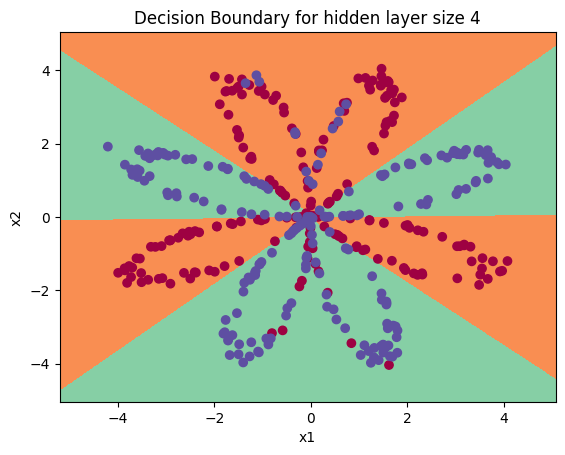

In [29]:
# Build a model with a n_h-dimensional hidden layer
parameters = nn_model(X, Y, n_h = 4, num_iterations = 10000, print_cost=True)

# Plot the decision boundary
plot_decision_boundary(lambda x: predict(parameters, x.T), X, Y)
plt.title("Decision Boundary for hidden layer size " + str(4))

In [ ]:
# Print accuracy

predictions = predict(parameters, X)
print ('Accuracy: %d' % float((np.dot(Y, predictions.T) + np.dot(1 - Y, 1 - predictions.T)) / float(Y.size) * 100) + '%')

In [34]:
predictions = predict(parameters, X)
accuracy = np.mean(predictions == Y) * 100
print('Accuracy: %d%%' % accuracy)

Accuracy: 90%


La precisión es realmente alta comparada con la Regresión Logística. ¡El modelo ha aprendido los patrones de los pétalos de la flor! A diferencia de la regresión logística, las redes neuronales pueden aprender fronteras de decisión incluso altamente no lineales.

### ¡Felicidades por terminar esta Tarea de Programación!

Aquí tienes un resumen rápido de todo lo que acabas de lograr:

- Construiste una red neuronal de clasificación de 2 clases completa con una capa oculta
- Hiciste buen uso de una unidad no lineal
- Calculaste la pérdida de entropía cruzada
- Implementaste propagación hacia adelante y hacia atrás
- Viste el impacto de variar el tamaño de la capa oculta, incluyendo el sobreajuste.

¡Has creado una red neuronal que puede aprender patrones! Excelente trabajo. A continuación, hay algunos ejercicios opcionales para probar con otros tamaños de capa oculta y otros conjuntos de datos.

<a name='6'></a>
## 6 - Ajustar el tamaño de la capa oculta (ejercicio opcional/no calificado)

Ejecuta el siguiente código (puede tardar 1-2 minutos). Luego, observa los diferentes comportamientos del modelo para varios tamaños de capa oculta.

<a name='6'></a>
## 6 - Tuning hidden layer size (optional/ungraded exercise)

Run the following code(it may take 1-2 minutes). Then, observe different behaviors of the model for various hidden layer sizes.

Accuracy for 1 hidden units: 67.5 %
Accuracy for 2 hidden units: 67.25 %
Accuracy for 3 hidden units: 90.75 %
Accuracy for 4 hidden units: 90.5 %
Accuracy for 5 hidden units: 91.25 %


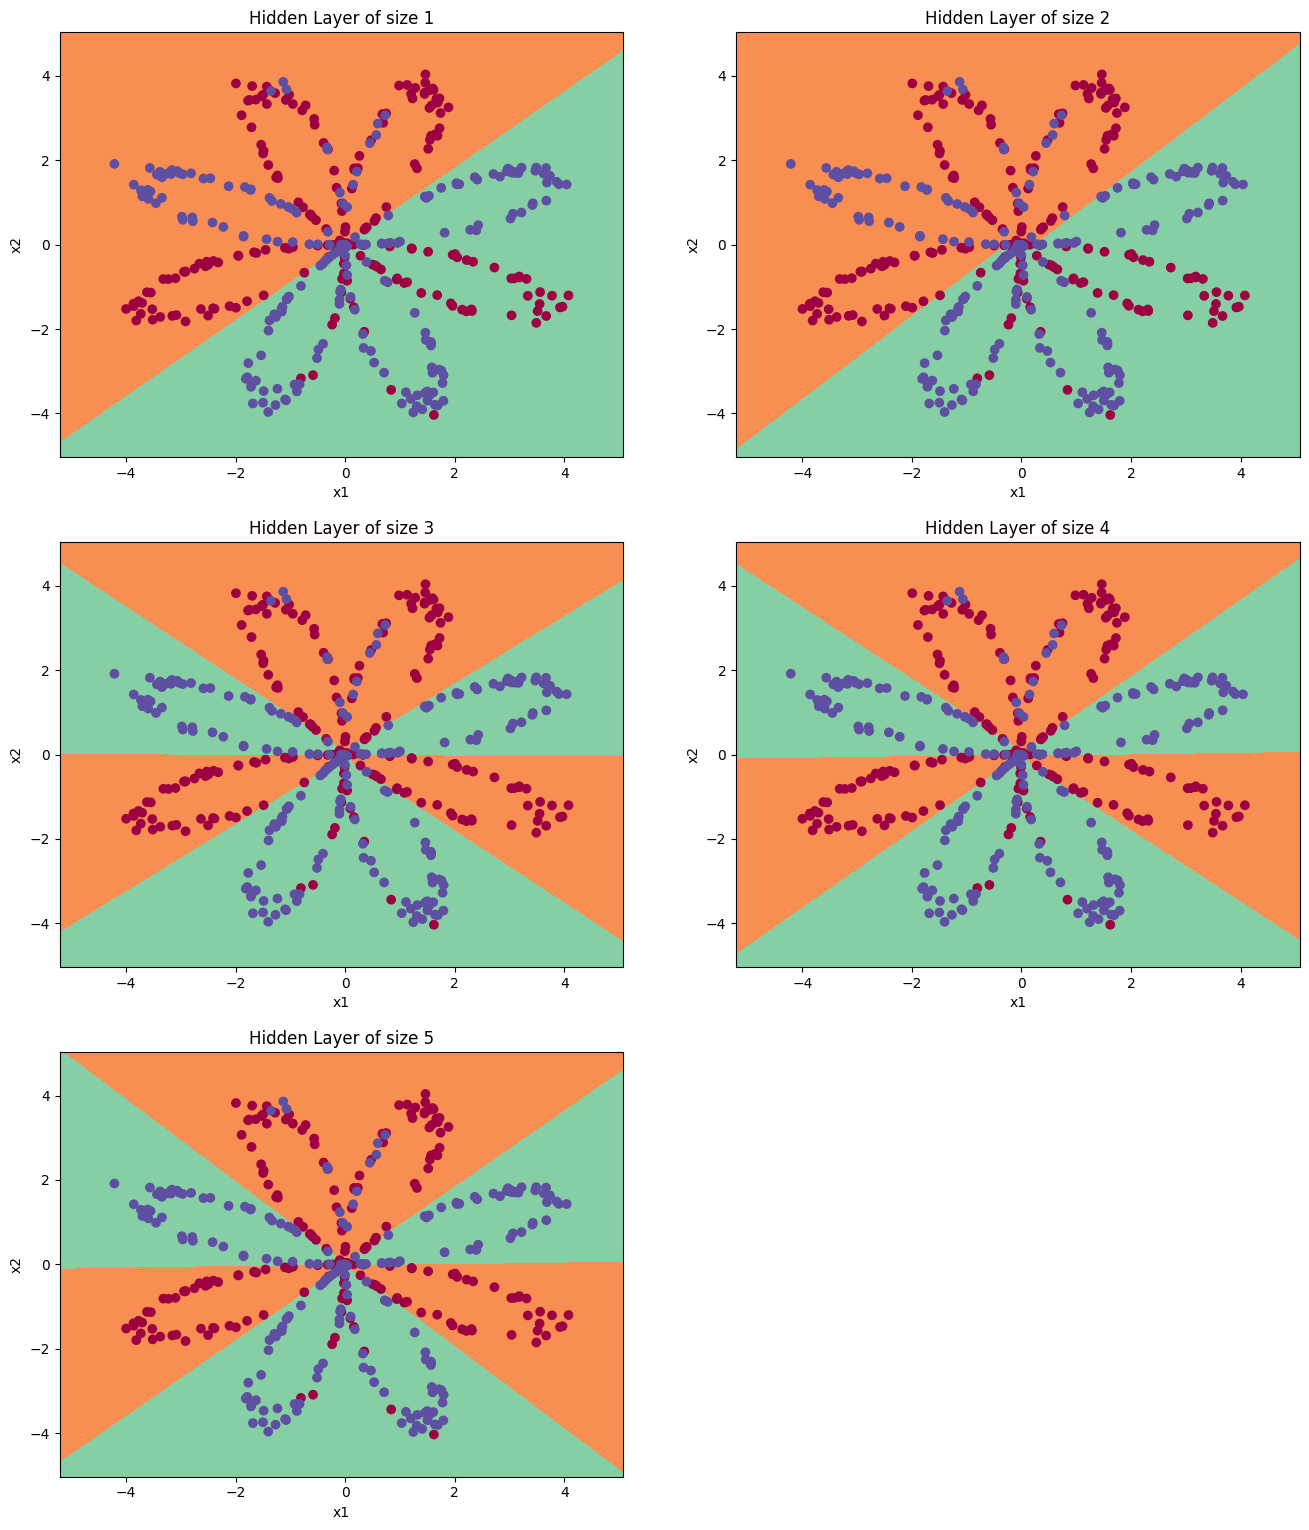

In [36]:
# This may take about 2 minutes to run

plt.figure(figsize=(16, 32))
hidden_layer_sizes = [1, 2, 3, 4, 5]

# you can try with different hidden layer sizes
# but make sure before you submit the assignment it is set as "hidden_layer_sizes = [1, 2, 3, 4, 5]"
# hidden_layer_sizes = [1, 2, 3, 4, 5, 20, 50]

for i, n_h in enumerate(hidden_layer_sizes):
    plt.subplot(5, 2, i+1)
    plt.title('Hidden Layer of size %d' % n_h)
    parameters = nn_model(X, Y, n_h, num_iterations = 5000)
    plot_decision_boundary(lambda x: predict(parameters, x.T), X, Y)
    predictions = predict(parameters, X)
    accuracy = np.mean(predictions == Y) * 100
    print ("Accuracy for {} hidden units: {} %".format(n_h, accuracy))

**Nota**: Recuerda enviar la tarea haciendo clic en el botón azul "Submit Assignment" en la esquina superior derecha.

**Algunas preguntas opcionales/no calificadas que puedes explorar si lo deseas**:
- ¿Qué sucede cuando cambias la activación tanh por una activación sigmoide o una activación ReLU?
- Juega con el learning_rate. ¿Qué sucede?
- ¿Qué pasa si cambiamos el conjunto de datos? (¡Mira la parte 7 abajo!)

<a name='7'></a>
## 7 - Rendimiento en otros conjuntos de datos

Si lo deseas, puedes volver a ejecutar todo el notebook (menos la parte del conjunto de datos) para cada uno de los siguientes conjuntos de datos.

If you want, you can rerun the whole notebook (minus the dataset part) for each of the following datasets.

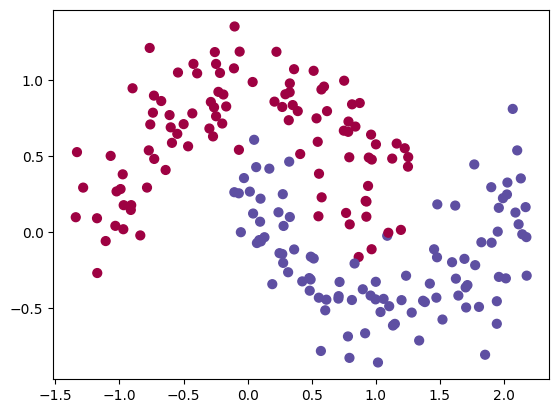

In [37]:
# Datasets
noisy_circles, noisy_moons, blobs, gaussian_quantiles, no_structure = load_extra_datasets()

datasets = {"noisy_circles": noisy_circles,
            "noisy_moons": noisy_moons,
            "blobs": blobs,
            "gaussian_quantiles": gaussian_quantiles}

### START CODE HERE ### (choose your dataset)
dataset = "noisy_moons"
### END CODE HERE ###

X, Y = datasets[dataset]
X, Y = X.T, Y.reshape(1, Y.shape[0])

# make blobs binary
if dataset == "blobs":
    Y = Y%2

# Visualize the data
plt.scatter(X[0, :], X[1, :], c=Y, s=40, cmap=plt.cm.Spectral);

**References**:

- http://cs231n.github.io/neural-networks-case-study/